In [1]:
from selenium import webdriver

driver = webdriver.Chrome()

driver.get("https://www.amazon.in/s?k=laptops")

print(driver.title)

driver.quit()

Amazon.in : laptops


In [2]:
from selenium import webdriver
from selenium.webdriver.chrome.options import Options as ChromeOptions
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import time

# Setup Chrome WebDriver
options = ChromeOptions()

driver = webdriver.Chrome(options=options)

Brand = []
Processor = []
RAM = []

# Loop through multiple Amazon pages
for page in range(1, 10): #scrapping amazon pages

    url = f"https://www.amazon.in/s?k=laptops&page={page}"

    print(f"Scraping page {page} ...")

    driver.get(url)

    time.sleep(3)

    html = driver.page_source
    soup = BeautifulSoup(html, "html.parser")

    products = soup.find_all("div", attrs={"data-component-type": "s-search-result"}x`)

    print("Products found:", len(products))

    for x in products:

        y = x.find("h2")

        if y:

            name = y.get_text(strip=True)

            if 'bag' in name.lower() or 'pillow' in name.lower():
                continue

            brand = name.split()[0]

            Brand.append(brand)

        else:
            Brand.append(np.nan)

df = pd.DataFrame({
    "Brand_name": Brand
})

print(df.shape)
print(df.head(20))

driver.quit()

Scraping page 1 ...
Products found: 22
Scraping page 2 ...
Products found: 25
Scraping page 3 ...
Products found: 25
Scraping page 4 ...
Products found: 25
Scraping page 5 ...
Products found: 25
Scraping page 6 ...
Products found: 25
Scraping page 7 ...
Products found: 25
Scraping page 8 ...
Products found: 25
Scraping page 9 ...
Products found: 25
(222, 1)
   Brand_name
0        ASUS
1        ASUS
2      Lenovo
3        Dell
4      Lenovo
5          HP
6        Dell
7        Dell
8          HP
9        ASUS
10       Acer
11     Lenovo
12       Acer
13       ASUS
14       Acer
15      EBook
16         HP
17       Acer
18       ASUS
19       ASUS


In [99]:
from selenium import webdriver
from selenium.webdriver.chrome.options import Options as ChromeOptions
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import re
import time

# Setup Chrome WebDriver
options = ChromeOptions()

driver = webdriver.Chrome(options=options)

Brand = []
processor = []
RAM = []
SSD=[]
Screen_Size=[]
Price=[]
Discount=[]
Rating=[]


# Loop through multiple Amazon pages
for page in range(1, 10):

    url = f"https://www.amazon.in/s?k=laptops&page={page}"

    print(f"Scraping page {page} ...")

    driver.get(url)

    time.sleep(3)

    html = driver.page_source
    soup = BeautifulSoup(html, "html.parser")

    products = soup.find_all("div", attrs={"data-component-type": "s-search-result"})

    print("Products found:", len(products))

    for x in products:
        y = x.find("h2")
        if y:
            name = y.get_text(strip=True)
            if 'bag' in name.lower() or 'pillow' in name.lower():
                continue
            brand = name.split()[0]
            Brand.append(brand)
        else:
            Brand.append(np.nan)
            
        y = x.find("h2")
        if y:
            name = y.text.strip()
            if 'bag' in name.lower() or 'pillow' in name.lower():
                continue
            reg = re.findall(r'M\d+(?:\s+(?:Pro|Max|Ultra))?|AMD Ryzen ?\d+[- ]?\d+[A-Za-z]*|Intel\s.*?(?:[UH]|N4500)|Core i\d-\d+[A-Z]*|Mediatek \d+|AMD \w+\w+ \d+[A-Z]|Celeron\s\w+|Snapdragon\s[A-Z]',y.text)
            if len(reg) != 0:
                processor.append(reg[0])
            else:
                processor.append(np.nan)

        if y:
            name = y.get_text(strip=True)

            # Skip unwanted products
            if 'bag' in name.lower() or 'pillow' in name.lower():
                continue

            reg = re.findall(
                r'\d+GB.+DDR\d'
                r'|\d+\sGB.+DDR\d'
                r'|\d+GB\sUnified Memory'
                r'|\d+GB\sRAM'
                r'|\d+\s?GB(?=[/|,])',
                name
            )

            if len(reg) != 0:
                RAM.append(reg[0])
            else:
                RAM.append(np.nan)

        if 'bag' in name.lower() or 'pillow' in name.lower():
            continue
        reg=re.findall(r'\d+\s?(?:GB|TB)?\s*(?:SSD|eMMC|NVMe)|\d+\sSSD',name)
        if len(reg)!=0:
            SSD.append(reg[0])
        else:
            SSD.append(np.nan)

        if 'bag' in name.lower() or 'pillow' in name.lower():
            continue
        reg=re.findall(r'\d+\.?\d?(?=″|"|\')|\d+\.\d?(?=\s?inch)|\d{2}(?=")',name)

        if len(reg)!=0:
            Screen_Size.append(reg[0])
        else:
            Screen_Size.append(np.nan)

        if 'bag' in name.lower() or 'pillow' in name.lower():
            continue
        price = x.find("span", class_="a-price")
        if price:
            price = price.find("span", class_="a-offscreen")
            if price:
                Price.append(price.text.strip())
        else:
            Price.append(np.nan)

        if 'bag' in name.lower() or 'pillow' in name.lower():
            continue
        y = x.find(string=re.compile(r'\d+%\s*off', re.I))
        
        if y:
            Discount.append(y.strip())
        else:
            Discount.append(np.nan)

        y = x.find(attrs={"aria-label": re.compile(r'\d+(?:\.\d+)?\s*out of 5', re.I)})
        if y:
            Rating.append(re.findall(r'\d+(?:\.\d+)?', y["aria-label"])[0])
        else:
            Rating.append(np.nan)


df = pd.DataFrame({"Brand_name": Brand, "Processor":processor, "RAM": RAM,"SSD":SSD, "Screen_Size":Screen_Size,"Price":Price, "Discount":Discount, "Rating":Rating})

print(df.shape)
print(df.head(20))

driver.quit()

Scraping page 1 ...
Products found: 22
Scraping page 2 ...
Products found: 25
Scraping page 3 ...
Products found: 25
Scraping page 4 ...
Products found: 25
Scraping page 5 ...
Products found: 25
Scraping page 6 ...
Products found: 25
Scraping page 7 ...
Products found: 25
Scraping page 8 ...
Products found: 25
Scraping page 9 ...
Products found: 25
(222, 8)
   Brand_name                        Processor                  RAM  \
0        ASUS             Intel Core 7 350,NPU             16GB RAM   
1        ASUS                     Intel Core U             16GB RAM   
2      Lenovo                AMD Ryzen 5 7520U                  NaN   
3        Dell        Intel Core i3/Core 3 100U            16GB DDR4   
4       Apple                               M5  16GB Unified Memory   
5       Apple                               M5  16GB Unified Memory   
6          HP  Intel (i3 14th Gen) Core 3 100U            8 GB DDR5   
7        Dell        Intel Core i3/Core 3 100U             8GB DDR4   
8

In [8]:
df

,Brand_name,Processor
0,ASUS,AMD Ryzen 7 7445HS
1,ASUS,Intel Core U
2,Dell,Intel Core i3/Core 3 100U
3,Lenovo,AMD Ryzen 5 7520U
4,Lenovo,AMD Ryzen 7 7735HS
...,...,...
217,ALKETRON,NaN
218,HP,Intel Core U
219,Lenovo,Intel Core i7-14650H
220,Dell,Intel 14th Gen Core i3 / Core 3 100U


In [16]:
df.to_csv("Amazon_Laptop_selenium_detailed.csv", index=False)
print("Data saved to 'Amazon_Laptop_selenium_detailed'")

Data saved to 'Amazon_Laptop_selenium_detailed'


In [100]:
df

,Brand_name,Processor,RAM,SSD,Screen_Size,Price,Discount,Rating
0,ASUS,"Intel Core 7 350,NPU",16GB RAM,512GB SSD,14,"₹1,18,990",(34% off),NaN
1,ASUS,Intel Core U,16GB RAM,1TB SSD,14,"₹1,89,990",(34% off),NaN
2,Lenovo,AMD Ryzen 5 7520U,NaN,NaN,15.6,"₹58,090",(39% off),4.0
3,Dell,Intel Core i3/Core 3 100U,16GB DDR4,512 SSD,15.6,"₹60,490",(17% off),4.0
4,Apple,M5,16GB Unified Memory,1TB SSD,13,"₹1,72,490",(7% off),4.7
...,...,...,...,...,...,...,...,...
217,Lenovo,Intel Core U,16GB RAM,512GB SSD,NaN,"₹98,990",(32% off),3.9
218,Lenovo,AMD Ryzen 7 260,16GB RAM,1TB SSD,NaN,"₹1,99,990",(3% off),3.5
219,ASUS,AMD Ryzen 7 8845HS,"4GB,16GB DDR5",512GB SSD,15.6,"₹1,07,990",(31% off),3.9
220,Lenovo,AMD Ryzen 5 7520U,16GB DDR5,512GB SSD,15.6,"₹59,999",(37% off),3.6


In [101]:
df.isnull().sum()

Brand_name      0
Processor      14
RAM             5
SSD            13
Screen_Size    22
Price           1
Discount       17
Rating         47
dtype: int64

In [102]:
df.dtypes

Brand_name     object
Processor      object
RAM            object
SSD            object
Screen_Size    object
Price          object
Discount       object
Rating         object
dtype: object

In [103]:
df['Price']=df['Price'].str.replace('[₹,]','',regex=True)

In [104]:
df['Price']

0      118990
1      189990
2       58090
3       60490
4      172490
        ...  
217     98990
218    199990
219    107990
220     59999
221     42100
Name: Price, Length: 222, dtype: object

In [105]:
df['Price'].dtype

dtype('O')

In [106]:
df['Price']=pd.to_numeric(df['Price'])
df['Price']

0      118990.0
1      189990.0
2       58090.0
3       60490.0
4      172490.0
         ...   
217     98990.0
218    199990.0
219    107990.0
220     59999.0
221     42100.0
Name: Price, Length: 222, dtype: float64

In [107]:
df['Price'].isnull().sum()

np.int64(1)

In [108]:
df['Discount']

0      (34% off)
1      (34% off)
2      (39% off)
3      (17% off)
4       (7% off)
         ...    
217    (32% off)
218     (3% off)
219    (31% off)
220    (37% off)
221    (29% off)
Name: Discount, Length: 222, dtype: object

In [109]:
df['Discount'].dtype

dtype('O')

In [110]:
df['Discount'].isnull().sum()

np.int64(17)

In [111]:
df['Discount'] = df['Discount'].str.extract(r'(\d+)%')

In [112]:
df['Discount']

0      34
1      34
2      39
3      17
4       7
       ..
217    32
218     3
219    31
220    37
221    29
Name: Discount, Length: 222, dtype: object

In [113]:
df['Discount'] = pd.to_numeric(df['Discount'])

In [114]:
df['Discount'].dtype

dtype('float64')

In [115]:
df['Discount']=df['Discount'].fillna(0)

In [116]:
df['Discount'].isnull().sum()

np.int64(0)

In [117]:
df['Rating']

0      NaN
1      NaN
2      4.0
3      4.0
4      4.7
      ... 
217    3.9
218    3.5
219    3.9
220    3.6
221    2.0
Name: Rating, Length: 222, dtype: object

In [118]:
df['Rating'].isnull().sum()

np.int64(47)

In [119]:
df['Rating'].dtype

dtype('O')

In [120]:
df['Rating']=pd.to_numeric(df['Rating'])

In [121]:
df['Rating'].dtype

dtype('float64')

In [122]:
df['Rating']=df['Rating'].fillna(0)

In [123]:
df['Rating']

0      0.0
1      0.0
2      4.0
3      4.0
4      4.7
      ... 
217    3.9
218    3.5
219    3.9
220    3.6
221    2.0
Name: Rating, Length: 222, dtype: float64

In [124]:
df['Screen_Size'].dtype

dtype('O')

In [125]:
df['Screen_Size']=pd.to_numeric(df['Screen_Size'])

In [126]:
df['Screen_Size'].dtype

dtype('float64')

In [127]:
df['Brand_name'].dtype

dtype('O')

In [79]:
df['Brand_name']=df['Brand_name'].str.title()

In [128]:
df['Brand_name'].value_counts()

Brand_name
HP            60
Lenovo        45
Apple         34
ASUS          31
Acer          24
Dell          12
acer           4
Samsung        3
MSI            3
Primebook      2
EBook          1
JioBook        1
𝗗𝗲𝗹𝗹Laptop     1
Alienware      1
Name: count, dtype: int64

In [129]:
df[df['Brand_name'].isin(['Alienware','EBook', 'Primebook', 'MSI'])]

,Brand_name,Processor,RAM,SSD,Screen_Size,Price,Discount,Rating
13,EBook,Celeron N4020,4GB DDR4,128GB eMMC,11.6,12990.0,48.0,3.3
69,Primebook,NaN,8GB RAM,NaN,NaN,28990.0,28.0,4.3
104,Primebook,NaN,8GB RAM,NaN,NaN,30990.0,31.0,4.3
130,MSI,Core i7-8750H,16GB,128GBSSD,NaN,124990.0,0.0,4.2
146,Alienware,Intel Core U,"32GB DDR5, 1TB SSD, NVIDIA GeForce RTX 5070, 8...",1TB SSD,16.0,319990.0,20.0,0.0
188,MSI,Intel 13th Gen. i5-13420H,16GB/1TB NVMe SSD/Windows 11 Home/NVIDIA GeFor...,1TB NVMe,NaN,89990.0,0.0,3.7
215,MSI,Intel 14th Gen. i9-14900H,16GB/1TB NVMe SSD/Windows 11 Home/NVIDIA GeFor...,1TB NVMe,NaN,219990.0,12.0,4.0


In [130]:
brand_count=df['Brand_name'].value_counts()

In [131]:
brand_count[brand_count<=3]

Brand_name
Samsung       3
MSI           3
Primebook     2
EBook         1
JioBook       1
𝗗𝗲𝗹𝗹Laptop    1
Alienware     1
Name: count, dtype: int64

In [132]:
df[df['Brand_name'].isin(brand_count[brand_count<=3].index)]

,Brand_name,Processor,RAM,SSD,Screen_Size,Price,Discount,Rating
13,EBook,Celeron N4020,4GB DDR4,128GB eMMC,11.6,12990.0,48.0,3.3
29,JioBook,Mediatek 8788,4GB RAM,64 eMMC,11.6,10990.0,56.0,2.8
31,Samsung,Intel Core U,16GB RAM,512GB SSD,14.0,112990.0,21.0,3.0
52,Samsung,Intel Core U,16GB RAM,512GB SSD,16.0,121590.0,26.0,2.5
69,Primebook,NaN,8GB RAM,NaN,NaN,28990.0,28.0,4.3
104,Primebook,NaN,8GB RAM,NaN,NaN,30990.0,31.0,4.3
119,Samsung,Intel Core i5 1335U,16GB RAM,512GB SSD,15.6,69990.0,15.0,4.0
130,MSI,Core i7-8750H,16GB,128GBSSD,NaN,124990.0,0.0,4.2
143,𝗗𝗲𝗹𝗹Laptop,NaN,8GB DDR4,256GB SSD,14.0,31995.0,47.0,0.0
146,Alienware,Intel Core U,"32GB DDR5, 1TB SSD, NVIDIA GeForce RTX 5070, 8...",1TB SSD,16.0,319990.0,20.0,0.0


In [135]:
df['Brand_name']=df['Brand_name'].replace('𝗗𝗲𝗹𝗹Laptop','Dell')

In [136]:
df['Brand_name'].value_counts()

Brand_name
HP           60
Lenovo       45
Apple        34
ASUS         31
Acer         24
Dell         13
acer          4
Samsung       3
MSI           3
Primebook     2
EBook         1
JioBook       1
Alienware     1
Name: count, dtype: int64

In [141]:
df[df['Brand_name'].isin(brand_count[brand_count<=3].index)]

,Brand_name,Processor,RAM,SSD,Screen_Size,Price,Discount,Rating
13,EBook,Celeron N4020,4GB DDR4,128GB eMMC,11.600000,12990.0,48.0,3.3
29,JioBook,Mediatek 8788,4GB RAM,64 eMMC,11.600000,10990.0,56.0,2.8
31,Samsung,Intel Core U,16GB RAM,512GB SSD,14.000000,112990.0,21.0,3.0
52,Samsung,Intel Core U,16GB RAM,512GB SSD,16.000000,121590.0,26.0,2.5
69,Primebook,NaN,8GB RAM,NaN,NaN,28990.0,28.0,4.3
104,Primebook,NaN,8GB RAM,NaN,NaN,30990.0,31.0,4.3
119,Samsung,Intel Core i5 1335U,16GB RAM,512GB SSD,15.600000,69990.0,15.0,4.0
130,MSI,Core i7-8750H,16GB,128GBSSD,NaN,124990.0,0.0,4.2
146,Alienware,Intel Core U,"32GB DDR5, 1TB SSD, NVIDIA GeForce RTX 5070, 8...",1TB SSD,16.000000,319990.0,20.0,0.0
188,MSI,Intel 13th Gen. i5-13420H,16GB/1TB NVMe SSD/Windows 11 Home/NVIDIA GeFor...,1TB NVMe,15.748031,89990.0,0.0,3.7


In [97]:
df[df['Brand_name'].isin(brand_count[brand_count<=2].index)]

,Brand_name,Processor,RAM,SSD,Screen_Size,Price,Discount,Rating,Screen_size


In [140]:
df.loc[[188,215], 'Screen_Size'] = 40/2.54

In [142]:
df[df['Processor'].isnull()]

,Brand_name,Processor,RAM,SSD,Screen_Size,Price,Discount,Rating
30,Acer,NaN,4GB RAM,64GB eMMC,11.6,19990.0,46.0,4.1
38,HP,NaN,4GB LPDDR5,NaN,14.0,25990.0,56.0,2.2
65,HP,NaN,8 GB DDR5,512GB SSD,15.6,47450.0,53.0,3.9
67,HP,NaN,8 GB DDR5,512 GB SSD,15.6,55990.0,31.0,0.0
69,Primebook,NaN,8GB RAM,NaN,NaN,28990.0,28.0,4.3
76,HP,NaN,8 GB DDR5,512 GB SSD,15.6,45450.0,55.0,2.9
104,Primebook,NaN,8GB RAM,NaN,NaN,30990.0,31.0,4.3
105,Lenovo,NaN,NaN,NaN,15.3,66450.0,30.0,4.4
109,Lenovo,NaN,16GB RAM,512GB SSD,15.6,64990.0,54.0,0.0
116,HP,NaN,8 GB DDR5,512 GB SSD,15.6,55990.0,31.0,0.0


In [162]:
df.loc[[30,38,65,69,104], 'Processor'] = 'MediaTek'
df.loc[75, 'Processor'] ='AMD Ryzen 3'
df.loc[[67,116], 'Processor'] ='Intel Core 3'
df.loc[76, 'Processor'] ='Intel'
df.loc[[109,125, 164], 'Processor']= 'AMD Ryzen 5'

In [163]:
df[df['Processor'].isnull()]

,Brand_name,Processor,RAM,SSD,Screen_Size,Price,Discount,Rating
105,Lenovo,NaN,NaN,NaN,15.3,66450.0,30.0,4.4
129,HP,NaN,"6GB RTX 4050, 16GB DDR4",512GB SSD,15.6,134990.0,0.0,4.1
143,Dell,NaN,8GB DDR4,256GB SSD,14.0,31995.0,47.0,0.0


In [190]:
Processor_count=df['Processor'].value_counts()

In [191]:
Processor_count

Processor
Intel Core U                     44
M5                               18
Intel Core i5-1334U              12
M5 Max                           10
Intel Core i5-13420H              7
                                 ..
Intel Celeron Dual Core N4500     1
Celeron N4020                     1
AMD Athlon Silver 7120U           1
Intel 13th Gen Core i5-1334U      1
Intel 14th Gen i9-14900H          1
Name: count, Length: 67, dtype: int64

In [196]:
Processor_count[Processor_count==2]

Processor
Intel Core i7-14650H                    2
Intel Core 5-210H                       2
Intel Core i7 13th Gen -1355U           2
Intel Core i3-1305U                     2
Intel Core 5-120U                       2
Intel Core i7-1355U                     2
AMD Ryzen 7 8845HS                      2
Intel Core i3-1315U                     2
AMD Ryzen 5 5500U                       2
AMD Ryzen 7 7730U                       2
Intel Core 5                            2
AMD Ryzen 7 7445HS                      2
MediaTek Kompanio 540                   2
Intel Core i3/Core 3 100U               2
AMD Ryzen 3 7320U                       2
Intel Core i5 13th Gen 13420H           2
AMD Ryzen 9                             2
AMD Ryzen 5-40                          2
Intel Core i7-13650H                    2
Intel 14th Gen Core i3 / Core 3 100U    2
Name: count, dtype: int64

In [182]:
df.loc[[15,21], 'Processor'] = 'MediaTek Kompanio 540'
df.loc[[17, 189,101, 88], 'Processor']= 'AMD Ryzen 3'
df.loc[[45], 'Processor']= 'Intel N50'
df.loc[[163, 50, 68, 33], 'Processor']= 'AMD Ryzen 5'
df.loc[[218, 170, 79], 'Processor']= 'AMD Ryzen 7'
df.loc[[191,192], 'Processor']= 'AMD Ryzen 9'
df.loc[12, 'Processor']= 'AMD Athlon Silver 7120U'

In [183]:
df['Processor'] = df['Processor'].str.replace(r',.*', '', regex=True)

In [184]:
df['Processor'] = df['Processor'].str.replace(r'\s+\d{2}(?:\.\d+)?".*$', '', regex=True)
df['Processor'] = df['Processor'].str.replace(r'\).*$', '', regex=True)
df['Processor'] = df['Processor'].str.replace(r'\bGen\.', 'Gen', regex=True)

In [210]:
Processor_count=df['Processor'].value_counts()
df[(df['Brand_name'] == 'Acer') &(df['Processor'].isin(Processor_count[Processor_count <= 1].index))]

,Brand_name,Processor,RAM,SSD,Screen_Size,Price,Discount,Rating
19,Acer,Intel Celeron Dual Core N4500,8 GB,256 GB SSD,11.6,33990.0,19.0,0.0
64,Acer,Intel Celeron- N4500,4GB LPDDR4,32GB eMMC,11.6,15990.0,54.0,3.0
89,Acer,Intel Core i3 13th Gen 1305U,16 GB,500 GB SSD,15.6,53990.0,33.0,0.0


In [208]:
df.loc[[6], 'Processor'] = 'Intel Core 3'
df.loc[[41], 'Processor'] = 'Intel Core 5'
df.loc[[51], 'Processor']= 'AMD Ryzen 3 7335U'
df.loc[[114], 'Processor']= 'Intel Core i7-1355U'
df.loc[[118], 'Processor']= 'AMD Athlon'
df.loc[[184], 'Processor']= 'Intel Core 3 100U'
df.loc[[194], 'Processor']= 'Intel Core i5-1334U'
df.loc[[205], 'Processor']= ' Intel Core 7-150U'
df.loc[[193], 'Processor']='Intel Core i9-12900H'
df.loc[[142], 'Processor']='Intel Core Ultra 5 226V'

In [206]:
df[df['Processor'].isin(Processor_count[Processor_count <= 1].index)]

,Brand_name,Processor,RAM,SSD,Screen_Size,Price,Discount,Rating
12,Lenovo,AMD Athlon Silver 7120U,8GB LPDDR5,512 GB SSD,15.600000,46999.0,53.0,4.0
13,EBook,Celeron N4020,4GB DDR4,128GB eMMC,11.600000,12990.0,48.0,3.3
19,Acer,Intel Celeron Dual Core N4500,8 GB,256 GB SSD,11.600000,33990.0,19.0,0.0
29,JioBook,Mediatek 8788,4GB RAM,64 eMMC,11.600000,10990.0,56.0,2.8
34,Lenovo,Intel Core i5 13420H,24GB RAM,1TB SSD,15.300000,87690.0,37.0,4.1
45,ASUS,Intel N50,8GB RAM,128GB SSD,14.000000,32990.0,37.0,3.7
51,HP,AMD Ryzen 3 7335U,16GB RAM DDR5,512GB SSD,15.600000,59380.0,42.0,4.3
64,Acer,Intel Celeron- N4500,4GB LPDDR4,32GB eMMC,11.600000,15990.0,54.0,3.0
76,HP,Intel,8 GB DDR5,512 GB SSD,15.600000,45450.0,55.0,2.9
89,Acer,Intel Core i3 13th Gen 1305U,16 GB,500 GB SSD,15.600000,53990.0,33.0,0.0


In [199]:
df.loc[[11], 'Processor'] ='Intel Core i5-1334U'
df.loc[[96], 'Processor']= 'Intel Core 7 240H'
df.loc[[141], 'Processor']='Intel Core i3-1305U'
df.loc[96, 'SSD']='512 GB SSD'


In [212]:
df.to_csv("Amazon_Laptop_selenium_detailed_processor.csv", index=False)
print("Data saved to 'Amazon_Laptop_selenium_detailed_processor'")

Data saved to 'Amazon_Laptop_selenium_detailed_processor'


In [197]:
def processor_group(x):
    if pd.isna(x):
        return np.nan
    
    x = x.lower()

    if 'core i3' in x or 'core 3' in x:
        return 'Intel Core 3/i3'
    elif 'core i5' in x or 'core 5' in x:
        return 'Intel Core 5/i5'
    elif 'core i7' in x or 'core 7' in x:
        return 'Intel Core 7/i7'
    elif 'core i9' in x or 'core 7' in x:
        return 'Intel Core 9/i9'
    elif 'core ultra' in x:
        return 'Intel Core Ultra'
    elif 'celeron' in x:
        return 'Intel Celeron'
    elif 'pentium' in x:
        return 'Intel Pentium'
    elif 'intel n' in x:
        return 'Intel N-series'
    elif 'ryzen 3' in x:
        return 'AMD Ryzen 3'
    elif 'ryzen 5' in x:
        return 'AMD Ryzen 5'
    elif 'ryzen 7' in x:
        return 'AMD Ryzen 7'
    elif 'ryzen 9' in x:
        return 'AMD Ryzen 9'
    elif 'athlon' in x:
        return 'AMD Athlon'
    elif x.startswith('m5'):
        return 'Apple M-series'
    elif 'mediatek' in x:
        return 'MediaTek'
    elif 'snapdragon' in x:
        return 'Snapdragon'
    else:
        return 'Other'

In [199]:
df1['Processor_group'] = df1['Processor'].apply(processor_group)
df1['Processor_group'].value_counts()

C:\Users\Ravi Teja G\AppData\Local\Temp\ipykernel_6704\2910638113.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Processor_group'] = df1['Processor'].apply(processor_group)


Processor_group
Other               31
Intel Core 5/i5     24
AMD Ryzen 5         16
Intel Core 7/i7     15
Intel Core 3/i3     15
AMD Ryzen 3         14
AMD Ryzen 7         12
MediaTek             8
Apple M-series       8
Intel Celeron        6
Snapdragon           3
AMD Athlon           2
AMD Ryzen 9          2
Intel N-series       1
Intel Core Ultra     1
Intel Pentium        1
Intel Core 9/i9      1
Name: count, dtype: int64

In [49]:
df

,Brand_name,Processor,RAM,SSD,Screen_Size,Price,Discount,Rating,Processor_group
0,ASUS,Intel Core 7 350,16GB RAM,512GB SSD,14.0,118990.0,34.0,0.0,Intel Core 7/i7
1,ASUS,Intel Core U,16GB RAM,1TB SSD,14.0,189990.0,34.0,0.0,Other
2,Lenovo,AMD Ryzen 5 7520U,NaN,NaN,15.6,58090.0,39.0,4.0,AMD Ryzen 5
3,Dell,Intel Core i3/Core 3 100U,16GB DDR4,512 SSD,15.6,60490.0,17.0,4.0,Intel Core 3/i3
4,Apple,M5,16GB Unified Memory,1TB SSD,13.0,172490.0,7.0,4.7,Apple M-series
...,...,...,...,...,...,...,...,...,...
217,Lenovo,Intel Core U,16GB RAM,512GB SSD,NaN,98990.0,32.0,3.9,Other
218,Lenovo,AMD Ryzen 7,16GB RAM,1TB SSD,NaN,199990.0,3.0,3.5,AMD Ryzen 7
219,ASUS,AMD Ryzen 7 8845HS,"4GB,16GB DDR5",512GB SSD,15.6,107990.0,31.0,3.9,AMD Ryzen 7
220,Lenovo,AMD Ryzen 5 7520U,16GB DDR5,512GB SSD,15.6,59999.0,37.0,3.6,AMD Ryzen 5


In [50]:
# RAM Cleaning
df['RAM'] = df['RAM'].str.extract(r'(\d+)', expand=False)

In [51]:
df['RAM'] = pd.to_numeric(df['RAM'])

In [52]:
df['RAM']

0      16.0
1      16.0
2       NaN
3      16.0
4      16.0
       ... 
217    16.0
218    16.0
219     4.0
220    16.0
221     8.0
Name: RAM, Length: 222, dtype: float64

In [18]:
df['SSD'].isin

<bound method Series.isin of 0      512GB SSD
1        1TB SSD
2            NaN
3        512 SSD
4        1TB SSD
         ...    
217    512GB SSD
218      1TB SSD
219    512GB SSD
220    512GB SSD
221    512GB SSD
Name: SSD, Length: 222, dtype: object>

In [235]:
#SSD Cleaning
df1['Storage_GB'] = df1['SSD'].str.extract(r'(\d+(?:\.\d+)?)')

df1['Storage_GB'] = pd.to_numeric(df1['Storage_GB'])

C:\Users\Ravi Teja G\AppData\Local\Temp\ipykernel_6704\2740578656.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Storage_GB'] = df1['SSD'].str.extract(r'(\d+(?:\.\d+)?)')
C:\Users\Ravi Teja G\AppData\Local\Temp\ipykernel_6704\2740578656.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Storage_GB'] = pd.to_numeric(df1['Storage_GB'])


In [236]:
df1.loc[df1['SSD'].str.contains('TB', case=False, na=False),'Storage_GB'] *= 1000

In [237]:
df1.loc[113]

Brand_name                 ASUS
Processor          Intel Core U
RAM                         8.0
SSD                        1 TB
Screen_Size                16.0
Price                  199990.0
Discount                   42.0
Rating                      4.4
Processor_group    Intel Core U
Storage_GB               1000.0
Name: 113, dtype: object

In [55]:
df[df['SSD'].str.contains('eMMC', case=False, na=False)]

,Brand_name,Processor,RAM,SSD,Screen_Size,Price,Discount,Rating,Processor_group,Storage_GB
13,EBook,Celeron N4020,4.0,128GB eMMC,11.6,12990.0,48.0,3.3,Intel Celeron,128.0
29,JioBook,Mediatek 8788,4.0,64 eMMC,11.6,10990.0,56.0,2.8,MediaTek,64.0
30,Acer,MediaTek,4.0,64GB eMMC,11.6,19990.0,46.0,4.1,MediaTek,64.0
64,Acer,Intel Celeron- N4500,4.0,32GB eMMC,11.6,15990.0,54.0,3.0,Intel Celeron,32.0


In [56]:
df[df['Storage_GB'].isnull()]

,Brand_name,Processor,RAM,SSD,Screen_Size,Price,Discount,Rating,Processor_group,Storage_GB
2,Lenovo,AMD Ryzen 5 7520U,NaN,NaN,15.6,58090.0,39.0,4.0,AMD Ryzen 5,NaN
33,Acer,AMD Ryzen 5,16.0,NaN,15.6,59990.0,33.0,4.0,AMD Ryzen 5,NaN
38,HP,MediaTek,4.0,NaN,14.0,25990.0,56.0,2.2,MediaTek,NaN
69,Primebook,MediaTek,8.0,NaN,NaN,28990.0,28.0,4.3,MediaTek,NaN
93,Acer,AMD Ryzen 3-7320U,NaN,NaN,NaN,43990.0,23.0,3.8,AMD Ryzen 3,NaN
104,Primebook,MediaTek,8.0,NaN,NaN,30990.0,31.0,4.3,MediaTek,NaN
105,Lenovo,NaN,NaN,NaN,15.3,66450.0,30.0,4.4,NaN,NaN
113,ASUS,Intel Core U,8.0,NaN,16.0,199990.0,42.0,4.4,Other,NaN
159,acer,Intel Core U,24.0,NaN,16.0,499990.0,0.0,4.4,Other,NaN
166,Acer,Intel Core i3-1305U,16.0,NaN,14.0,52990.0,29.0,4.3,Intel Core 3/i3,NaN


In [58]:
df.loc[[2], 'RAM'] = '16'
df.loc[[93], 'RAM'] = '8'
df.loc[[2,33, 166], 'SSD'] = '512'
df.loc[[38,69,104], 'SSD'] = '128'
df.loc[[93], 'SSD'] = '256'
df.loc[[113,159,190,191], 'SSD'] = '1 TB'

In [78]:
df[(df['Brand_name'] == 'Apple') &(df['Processor'].index)]

,Brand_name,Processor,RAM,SSD,Screen_Size,Price,Discount,Rating,Processor_group,Storage_GB
5,Apple,M5,16.0,512GB SSD,15.0,166990.0,7.0,4.8,Apple M-series,512.0
9,Apple,M5 Max,36.0,2TB SSD,14.2,464490.0,7.0,5.0,Apple M-series,2000.0
23,Apple,M5,16.0,1TB SSD,13.0,172490.0,7.0,4.7,Apple M-series,1000.0
27,Apple,M5 Max,48.0,2TB SSD,16.2,589990.0,5.0,4.4,Apple M-series,2000.0
47,Apple,M5,16.0,1TB SSD,15.0,200990.0,7.0,4.8,Apple M-series,1000.0
49,Apple,M5,16.0,1TB SSD,13.0,172490.0,7.0,4.7,Apple M-series,1000.0
73,Apple,M5,16.0,512GB SSD,15.0,166990.0,7.0,4.8,Apple M-series,512.0
85,Apple,M5 Max,48.0,2TB SSD,16.2,589990.0,5.0,4.4,Apple M-series,2000.0
97,Apple,M5,16.0,1TB SSD,13.0,172490.0,7.0,4.7,Apple M-series,1000.0
99,Apple,M5,16.0,1TB SSD,15.0,200990.0,7.0,4.8,Apple M-series,1000.0


In [25]:
df[(df['Brand_name'] == 'Apple') &(df['Processor'].index)]

,Brand_name,Processor,RAM,SSD,Screen_Size,Price,Discount,Rating,Processor_group,Storage_GB
5,Apple,M5,16.0,512GB SSD,15.0,166990.0,7.0,4.8,Apple M-series,512.0
9,Apple,M5 Max,36.0,2TB SSD,14.2,464490.0,7.0,5.0,Apple M-series,2000.0
23,Apple,M5,16.0,1TB SSD,13.0,172490.0,7.0,4.7,Apple M-series,1000.0
27,Apple,M5 Max,48.0,2TB SSD,16.2,589990.0,5.0,4.4,Apple M-series,2000.0
47,Apple,M5,16.0,1TB SSD,15.0,200990.0,7.0,4.8,Apple M-series,1000.0
49,Apple,M5,16.0,1TB SSD,13.0,172490.0,7.0,4.7,Apple M-series,1000.0
73,Apple,M5,16.0,512GB SSD,15.0,166990.0,7.0,4.8,Apple M-series,512.0
85,Apple,M5 Max,48.0,2TB SSD,16.2,589990.0,5.0,4.4,Apple M-series,2000.0
97,Apple,M5,16.0,1TB SSD,13.0,172490.0,7.0,4.7,Apple M-series,1000.0
99,Apple,M5,16.0,1TB SSD,15.0,200990.0,7.0,4.8,Apple M-series,1000.0


In [60]:
df.loc[[15,21,29,30,38,65,69,104], 'Processor_group'] = 'Mediatek'

In [61]:
df[df['Processor'].str.contains('Mediatek', case=False, na=False)]

,Brand_name,Processor,RAM,SSD,Screen_Size,Price,Discount,Rating,Processor_group,Storage_GB
15,ASUS,MediaTek Kompanio 540,4.0,64GB SSD,14.0,20990.0,45.0,4.1,Mediatek,64.0
21,ASUS,MediaTek Kompanio 540,4.0,64GB SSD,15.6,22990.0,28.0,4.0,Mediatek,64.0
29,JioBook,Mediatek 8788,4.0,64 eMMC,11.6,10990.0,56.0,2.8,Mediatek,64.0
30,Acer,MediaTek,4.0,64GB eMMC,11.6,19990.0,46.0,4.1,Mediatek,64.0
38,HP,MediaTek,4.0,128,14.0,25990.0,56.0,2.2,Mediatek,NaN
65,HP,MediaTek,8.0,512GB SSD,15.6,47450.0,53.0,3.9,Mediatek,512.0
69,Primebook,MediaTek,8.0,128,NaN,28990.0,28.0,4.3,Mediatek,NaN
104,Primebook,MediaTek,8.0,128,NaN,30990.0,31.0,4.3,Mediatek,NaN


In [79]:
df[df['Screen_Size'].isnull()]

,Brand_name,Processor,RAM,SSD,Screen_Size,Price,Discount,Rating,Processor_group,Storage_GB
40,Lenovo,Intel Core i5 13th Gen 13420H,16.0,512 GB SSD,NaN,71190.0,35.0,3.6,Intel Core 5/i5,512.0
93,Acer,AMD Ryzen 3-7320U,8,256,NaN,43990.0,23.0,3.8,AMD Ryzen 3,NaN
112,Lenovo,Intel Core i7-14650H,32.0,1TB SSD,NaN,231490.0,19.0,4.0,Intel Core 7/i7,1000.0


In [63]:
df.loc[[36,217], 'Screen_Size'] = 16
df.loc[[39,195], 'Screen_Size'] = 16
df.loc[[218,167,88,214,104,126,130], 'Screen_Size'] = 15.6
df.loc[[142,134,56,103,189], 'Screen_Size'] = 14
df.loc[[69], 'Screen_Size'] = 14.1

In [64]:
df.loc[[63], 'RAM'] = '16'
df.loc[[101], 'RAM'] = '8'

In [65]:
df['Screen_Size'] = pd.to_numeric(df['Screen_Size'])
df['Screen_Size'].dtype

dtype('float64')

In [66]:
df['Screen_Size'] = df['Screen_Size'].round(1)
df['Screen_Size'].value_counts().sort_index()

Screen_Size
11.6     5
13.0     9
14.0    58
14.1     1
14.2     7
15.0     9
15.3    13
15.6    84
15.7     2
16.0    21
16.2     9
17.3     1
Name: count, dtype: int64

In [67]:
df[df['Discount'].isnull()]

,Brand_name,Processor,RAM,SSD,Screen_Size,Price,Discount,Rating,Processor_group,Storage_GB


In [68]:
df['Discount'].dtype

dtype('float64')

In [69]:
df['Discount'] = pd.to_numeric(df['Discount'], errors='coerce')

In [70]:
df['Discount']

0      34.0
1      34.0
2      39.0
3      17.0
4       7.0
       ... 
217    32.0
218     3.0
219    31.0
220    37.0
221    29.0
Name: Discount, Length: 222, dtype: float64

In [71]:
#Rating
df[df['Rating'].isnull()]

,Brand_name,Processor,RAM,SSD,Screen_Size,Price,Discount,Rating,Processor_group,Storage_GB


In [72]:
df['Rating'].dtype

dtype('float64')

In [73]:
df['Rating'] = pd.to_numeric(df['Rating'])

In [74]:
df['Rating'].value_counts().sort_index()

Rating
0.0    47
1.0     2
1.7     1
2.0     1
2.2     1
2.4     1
2.5     1
2.6     2
2.7     2
2.8     1
2.9     1
3.0     3
3.2     1
3.3     6
3.4     7
3.5     2
3.6     9
3.7     5
3.8    12
3.9    15
4.0    23
4.1    12
4.2     8
4.3     8
4.4    14
4.5     5
4.6     6
4.7     7
4.8    11
5.0     8
Name: count, dtype: int64

In [80]:
df

,Brand_name,Processor,RAM,SSD,Screen_Size,Price,Discount,Rating,Processor_group,Storage_GB
0,ASUS,Intel Core 7 350,16.0,512GB SSD,14.0,118990.0,34.0,0.0,Intel Core 7/i7,512.0
1,ASUS,Intel Core U,16.0,1TB SSD,14.0,189990.0,34.0,0.0,Other,1000.0
2,Lenovo,AMD Ryzen 5 7520U,16,512,15.6,58090.0,39.0,4.0,AMD Ryzen 5,NaN
3,Dell,Intel Core i3/Core 3 100U,16.0,512 SSD,15.6,60490.0,17.0,4.0,Intel Core 3/i3,512.0
4,Apple,M5,16.0,1TB SSD,13.0,172490.0,7.0,4.7,Apple M-series,1000.0
...,...,...,...,...,...,...,...,...,...,...
217,Lenovo,Intel Core U,16.0,512GB SSD,16.0,98990.0,32.0,3.9,Other,512.0
218,Lenovo,AMD Ryzen 7,16.0,1TB SSD,15.6,199990.0,3.0,3.5,AMD Ryzen 7,1000.0
219,ASUS,AMD Ryzen 7 8845HS,4.0,512GB SSD,15.6,107990.0,31.0,3.9,AMD Ryzen 7,512.0
220,Lenovo,AMD Ryzen 5 7520U,16.0,512GB SSD,15.6,59999.0,37.0,3.6,AMD Ryzen 5,512.0


In [81]:
df.to_csv("Amazon_Laptop_selenium_detailed_cleaned DF.csv", index=False)
print("Data saved to 'Cleaned DF Amazon_Laptop_selenium_detailed'")

Data saved to 'Cleaned DF Amazon_Laptop_selenium_detailed'


## Analysis
Brand-wise pricing

In [301]:
import matplotlib.pyplot as plt
import seaborn as sns

In [295]:
df['Brand_name'].value_counts()

Brand_name
HP           60
Lenovo       45
Apple        34
ASUS         31
Acer         24
Dell         13
acer          4
Samsung       3
MSI           3
Primebook     2
EBook         1
JioBook       1
Alienware     1
Name: count, dtype: int64

In [299]:
df['Price'] = df['Price'].round(1)

In [300]:
df.groupby('Brand_name')['Price'].mean().sort_values(ascending=False)

Brand_name
Apple        324225.294118
Alienware    319990.000000
acer         167465.000000
ASUS         148441.612903
MSI          144990.000000
Samsung      101523.333333
HP            96173.949153
Lenovo        95777.377778
Dell          72511.153846
Acer          46722.416667
Primebook     29990.000000
EBook         12990.000000
JioBook       10990.000000
Name: Price, dtype: float64

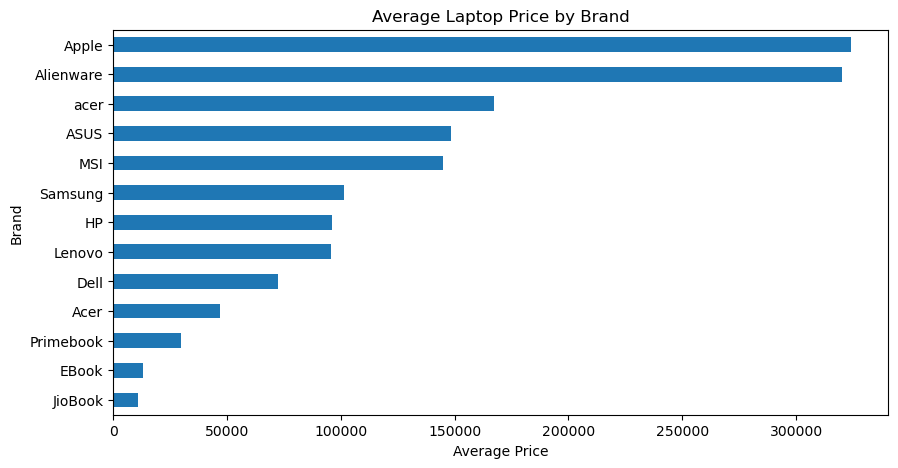

In [302]:
brand_price = df.groupby('Brand_name')['Price'].mean().sort_values()
brand_price.plot(kind='barh', figsize=(10,5))

plt.xlabel('Average Price')
plt.ylabel('Brand')
plt.title('Average Laptop Price by Brand')
plt.show()

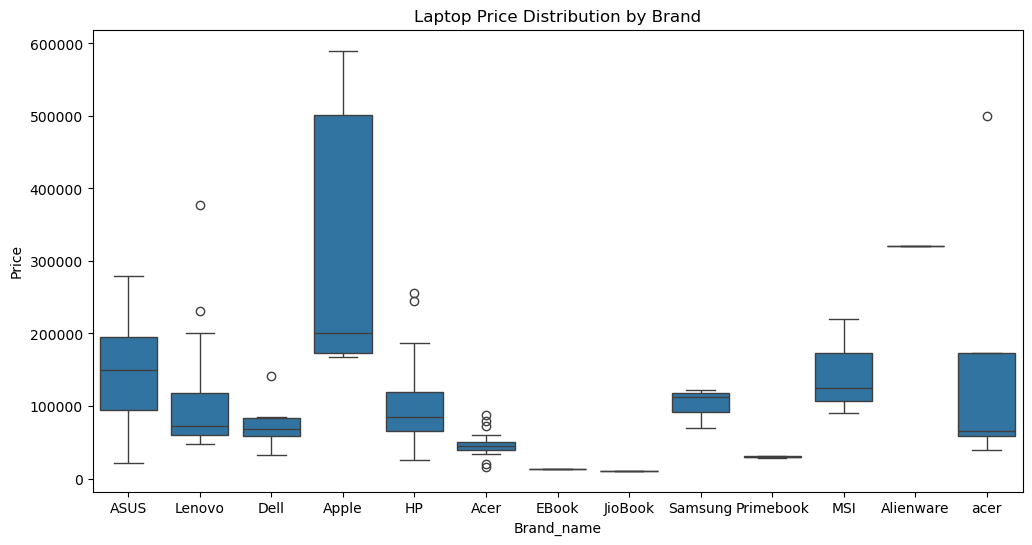

In [303]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df, x='Brand_name', y='Price')

plt.title('Laptop Price Distribution by Brand')
plt.show()

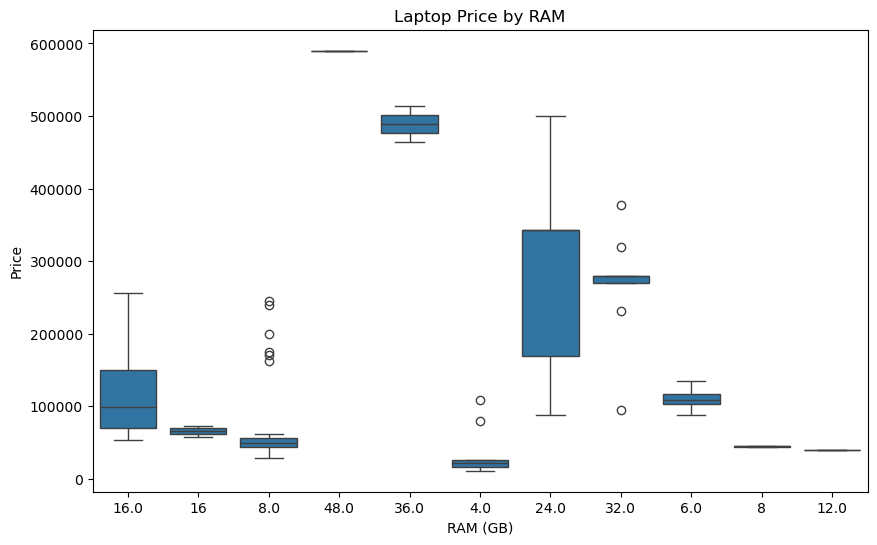

In [304]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df, x='RAM', y='Price')

plt.xlabel('RAM (GB)')
plt.ylabel('Price')
plt.title('Laptop Price by RAM')

plt.show()

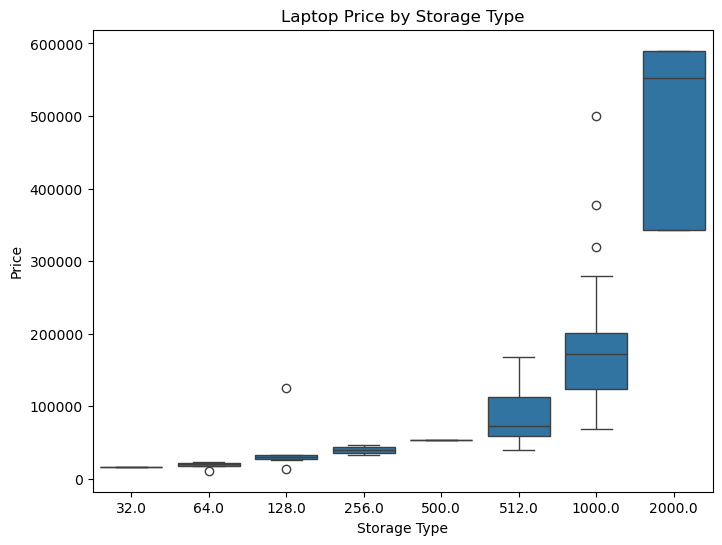

In [307]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df,x='Storage_GB',y='Price')

plt.xlabel('Storage Type')
plt.ylabel('Price')
plt.title('Laptop Price by Storage Type')
plt.show()

In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("Amazon_Laptop_selenium_detailed_processor.csv")

In [4]:
df

,Brand_name,Processor,RAM,SSD,Screen_Size,Price,Discount,Rating
0,ASUS,Intel Core 7 350,16GB RAM,512GB SSD,14.0,118990.0,34.0,0.0
1,ASUS,Intel Core U,16GB RAM,1TB SSD,14.0,189990.0,34.0,0.0
2,Lenovo,AMD Ryzen 5 7520U,NaN,NaN,15.6,58090.0,39.0,4.0
3,Dell,Intel Core i3/Core 3 100U,16GB DDR4,512 SSD,15.6,60490.0,17.0,4.0
4,Apple,M5,16GB Unified Memory,1TB SSD,13.0,172490.0,7.0,4.7
...,...,...,...,...,...,...,...,...
217,Lenovo,Intel Core U,16GB RAM,512GB SSD,NaN,98990.0,32.0,3.9
218,Lenovo,AMD Ryzen 7,16GB RAM,1TB SSD,NaN,199990.0,3.0,3.5
219,ASUS,AMD Ryzen 7 8845HS,"4GB,16GB DDR5",512GB SSD,15.6,107990.0,31.0,3.9
220,Lenovo,AMD Ryzen 5 7520U,16GB DDR5,512GB SSD,15.6,59999.0,37.0,3.6


In [170]:
df1=pd.read_csv("Amazon_Laptop_selenium_detailed_cleaned DF.csv")

In [171]:
df1

,Brand_name,Processor,RAM,SSD,Screen_Size,Price,Discount,Rating,Processor_group,Storage_GB
0,ASUS,Intel Core 7 350,16.0,512GB SSD,14.0,118990.0,34.0,0.0,Intel Core 7/i7,512.0
1,ASUS,Intel Core U,16.0,1TB SSD,14.0,189990.0,34.0,0.0,Other,1000.0
2,Lenovo,AMD Ryzen 5 7520U,16.0,512,15.6,58090.0,39.0,4.0,AMD Ryzen 5,NaN
3,Dell,Intel Core i3/Core 3 100U,16.0,512 SSD,15.6,60490.0,17.0,4.0,Intel Core 3/i3,512.0
4,Apple,M5,16.0,1TB SSD,13.0,172490.0,7.0,4.7,Apple M-series,1000.0
...,...,...,...,...,...,...,...,...,...,...
217,Lenovo,Intel Core U,16.0,512GB SSD,16.0,98990.0,32.0,3.9,Other,512.0
218,Lenovo,AMD Ryzen 7,16.0,1TB SSD,15.6,199990.0,3.0,3.5,AMD Ryzen 7,1000.0
219,ASUS,AMD Ryzen 7 8845HS,4.0,512GB SSD,15.6,107990.0,31.0,3.9,AMD Ryzen 7,512.0
220,Lenovo,AMD Ryzen 5 7520U,16.0,512GB SSD,15.6,59999.0,37.0,3.6,AMD Ryzen 5,512.0


In [175]:
df1.isnull().sum()

Brand_name          0
Processor           3
RAM                 1
SSD                 1
Screen_Size         3
Price               1
Discount            0
Rating              0
Processor_group     3
Storage_GB         12
dtype: int64

In [176]:
df.duplicated().sum()

np.int64(0)

In [177]:
df = df.drop_duplicates()

In [178]:
df = df.drop_duplicates().reset_index(drop=True)

In [179]:
df1[df1.duplicated()]

,Brand_name,Processor,RAM,SSD,Screen_Size,Price,Discount,Rating,Processor_group,Storage_GB
22,Apple,M5,16.0,512GB SSD,15.0,166990.0,7.0,4.8,Apple M-series,512.0
23,Apple,M5,16.0,1TB SSD,13.0,172490.0,7.0,4.7,Apple M-series,1000.0
27,Apple,M5 Max,48.0,2TB SSD,16.2,589990.0,5.0,4.4,Apple M-series,2000.0
35,HP,Intel Core U,24.0,1TB SSD,14.0,89999.0,35.0,3.6,Other,1000.0
48,Apple,M5 Pro,24.0,2TB SSD,14.2,342490.0,5.0,4.6,Apple M-series,2000.0
...,...,...,...,...,...,...,...,...,...,...
206,HP,Intel Core i5-1334U,16.0,1TB SSD,15.6,68990.0,12.0,3.9,Intel Core 5/i5,1000.0
207,ASUS,Intel Core 7 350,16.0,512GB SSD,14.0,118990.0,34.0,0.0,Intel Core 7/i7,512.0
210,Lenovo,Intel Core U,16.0,512GB SSD,15.3,117600.0,47.0,0.0,Other,512.0
211,HP,Intel Core U,16.0,512GB SSD,14.0,119990.0,32.0,0.0,Other,512.0


In [180]:
df1.duplicated().sum()

np.int64(62)

In [181]:
df1 = df1.drop_duplicates()

In [182]:
df1

,Brand_name,Processor,RAM,SSD,Screen_Size,Price,Discount,Rating,Processor_group,Storage_GB
0,ASUS,Intel Core 7 350,16.0,512GB SSD,14.0,118990.0,34.0,0.0,Intel Core 7/i7,512.0
1,ASUS,Intel Core U,16.0,1TB SSD,14.0,189990.0,34.0,0.0,Other,1000.0
2,Lenovo,AMD Ryzen 5 7520U,16.0,512,15.6,58090.0,39.0,4.0,AMD Ryzen 5,NaN
3,Dell,Intel Core i3/Core 3 100U,16.0,512 SSD,15.6,60490.0,17.0,4.0,Intel Core 3/i3,512.0
4,Apple,M5,16.0,1TB SSD,13.0,172490.0,7.0,4.7,Apple M-series,1000.0
...,...,...,...,...,...,...,...,...,...,...
216,Acer,AMD Ryzen 3-5400U,8.0,512GB SSD,15.6,44490.0,25.0,1.0,AMD Ryzen 3,512.0
218,Lenovo,AMD Ryzen 7,16.0,1TB SSD,15.6,199990.0,3.0,3.5,AMD Ryzen 7,1000.0
219,ASUS,AMD Ryzen 7 8845HS,4.0,512GB SSD,15.6,107990.0,31.0,3.9,AMD Ryzen 7,512.0
220,Lenovo,AMD Ryzen 5 7520U,16.0,512GB SSD,15.6,59999.0,37.0,3.6,AMD Ryzen 5,512.0


In [186]:
df1['Screen_Size'].median()

15.6

In [185]:
df1['Screen_Size'] = df1['Screen_Size'].fillna(df1['Screen_Size'].median())

C:\Users\Ravi Teja G\AppData\Local\Temp\ipykernel_6704\1943092258.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Screen_Size'] = df1['Screen_Size'].fillna(df1['Screen_Size'].median())


In [194]:
df1['Processor'].mode()

0    Intel Core U
Name: Processor, dtype: object

In [193]:
df1[df1['Processor'].isnull()]

,Brand_name,Processor,RAM,SSD,Screen_Size,Price,Discount,Rating,Processor_group,Storage_GB
105,Lenovo,NaN,NaN,NaN,15.3,66450.0,30.0,4.4,NaN,NaN
129,HP,NaN,6.0,512GB SSD,15.6,134990.0,0.0,4.1,NaN,512.0
143,Dell,NaN,8.0,256GB SSD,14.0,31995.0,47.0,0.0,NaN,256.0


In [196]:
df1.loc[[105,129,143],'Processor']='Intel Core U'

In [209]:
df1.loc[105]

Brand_name               Lenovo
Processor          Intel Core U
RAM                         NaN
SSD                         NaN
Screen_Size                15.3
Price                   66450.0
Discount                   30.0
Rating                      4.4
Processor_group    Intel Core U
Storage_GB                  NaN
Name: 105, dtype: object

In [210]:
#RAM Missing values
df1['RAM'].isnull().sum()

np.int64(1)

In [211]:
df1[df1['RAM'].isnull()]

,Brand_name,Processor,RAM,SSD,Screen_Size,Price,Discount,Rating,Processor_group,Storage_GB
105,Lenovo,Intel Core U,NaN,NaN,15.3,66450.0,30.0,4.4,Intel Core U,NaN


In [214]:
print(df1['RAM'].mode())
df1['RAM'].median()

0    16.0
Name: RAM, dtype: float64


16.0

In [215]:
df1.loc[105, 'RAM']=16

In [238]:
df1[df1['Storage_GB'].isnull()]

,Brand_name,Processor,RAM,SSD,Screen_Size,Price,Discount,Rating,Processor_group,Storage_GB
105,Lenovo,Intel Core U,16.0,NaN,15.3,66450.0,30.0,4.4,Intel Core U,NaN


In [220]:
df1['SSD'].mode()

0    512GB SSD
Name: SSD, dtype: object

In [239]:
df1.loc[105, 'Storage_GB'] = 512

In [240]:
df1.loc[105]

Brand_name               Lenovo
Processor          Intel Core U
RAM                        16.0
SSD                         NaN
Screen_Size                15.3
Price                   66450.0
Discount                   30.0
Rating                      4.4
Processor_group    Intel Core U
Storage_GB                512.0
Name: 105, dtype: object

In [ ]:
df1.loc[[188,215], 'Screen_Size'] = 40/2.54

In [292]:
df1.loc[188]

Brand_name                              MSI
Processor          Intel 13th Gen i5-13420H
RAM                                    16.0
SSD                                1TB NVMe
Screen_Size                            15.7
Price                               89990.0
Discount                                0.0
Rating                                  3.7
Processor_group             Intel Core 5/i5
Storage_GB                           1000.0
Laptop_segment                  Not_Premium
rating_group                        Average
Name: 188, dtype: object

In [241]:
df1.isnull().sum()

Brand_name         0
Processor          0
RAM                0
SSD                1
Screen_Size        0
Price              1
Discount           0
Rating             0
Processor_group    0
Storage_GB         0
dtype: int64

In [243]:
Q1 = df1['Price'].quantile(0.25)
Q3 = df1['Price'].quantile(0.75)
print(Q1,Q3)

53595.0 119690.0


In [245]:
IQR = Q3 - Q1
IQR

np.float64(66095.0)

In [246]:
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print(lower, upper)

-45547.5 218832.5


In [248]:
outliers = df1[(df1['Price'] < lower) | (df1['Price'] > upper)]
print(outliers)

    Brand_name                 Processor   RAM       SSD  Screen_Size  \
8        Apple                    M5 Max  48.0   2TB SSD         16.2   
9        Apple                    M5 Max  36.0   2TB SSD         14.2   
24       Apple                    M5 Pro  24.0   2TB SSD         14.2   
28        ASUS              Intel Core U  32.0   1TB SSD         14.0   
112     Lenovo      Intel Core i7-14650H  32.0   1TB SSD         15.6   
133      Apple                    M5 Max  36.0   2TB SSD         16.2   
137         HP              Intel Core U   8.0   1TB SSD         16.0   
146  Alienware              Intel Core U  32.0   1TB SSD         16.0   
159       acer              Intel Core U  24.0      1 TB         16.0   
190       ASUS                      M365  32.0      1 TB         14.0   
191       ASUS               AMD Ryzen 9   8.0      1 TB         16.0   
193     Lenovo      Intel Core i9-12900H  32.0   1TB SSD         16.0   
195         HP      Intel Core i7-12700H  16.0   1T

In [14]:
df1['Brand_name']=df1['Brand_name'].replace('acer','Acer')

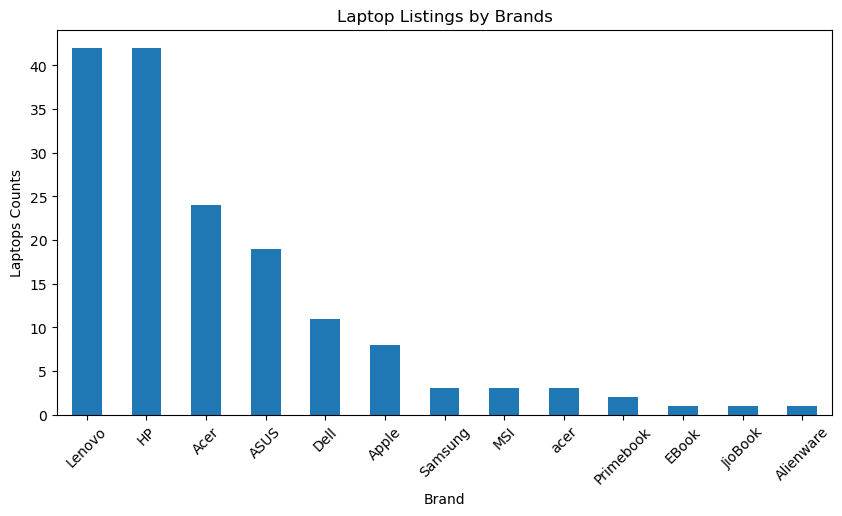

In [249]:
df1['Brand_name'].value_counts().plot(kind='bar',figsize=(10,5))
plt.xlabel('Brand')
plt.ylabel('Laptops Counts')
plt.title('Laptop Listings by Brands')
plt.xticks(rotation=45)
plt.show()

[Text(0, 0, '42'),
 Text(0, 0, '42'),
 Text(0, 0, '24'),
 Text(0, 0, '19'),
 Text(0, 0, '11'),
 Text(0, 0, '8'),
 Text(0, 0, '3'),
 Text(0, 0, '3'),
 Text(0, 0, '3'),
 Text(0, 0, '2'),
 Text(0, 0, '1'),
 Text(0, 0, '1'),
 Text(0, 0, '1')]

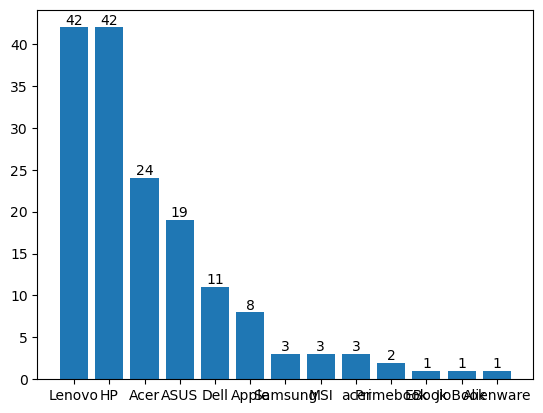

In [250]:
brand_counts = df1['Brand_name'].value_counts()

bars = plt.bar(brand_counts.index, brand_counts.values)

plt.bar_label(bars)


In [38]:
brand_price = df.groupby('Brand_name')['Price'].mean().sort_values().round(1)

brand_price

Brand_name
JioBook       10990.0
EBook         12990.0
Primebook     29990.0
Acer          63971.4
Dell          72511.2
Lenovo        95777.4
HP            96173.9
Samsung      101523.3
MSI          144990.0
ASUS         148441.6
Alienware    319990.0
Apple        324225.3
Name: Price, dtype: float64

In [251]:
brand_price = df1.groupby('Brand_name')['Price'].mean().sort_values()

brand_price

Brand_name
JioBook       10990.000000
EBook         12990.000000
Primebook     29990.000000
Acer          46722.416667
Dell          72809.545455
HP            94303.268293
Lenovo        94661.714286
Samsung      101523.333333
ASUS         128937.368421
MSI          144990.000000
acer         201623.333333
Alienware    319990.000000
Apple        330802.500000
Name: Price, dtype: float64

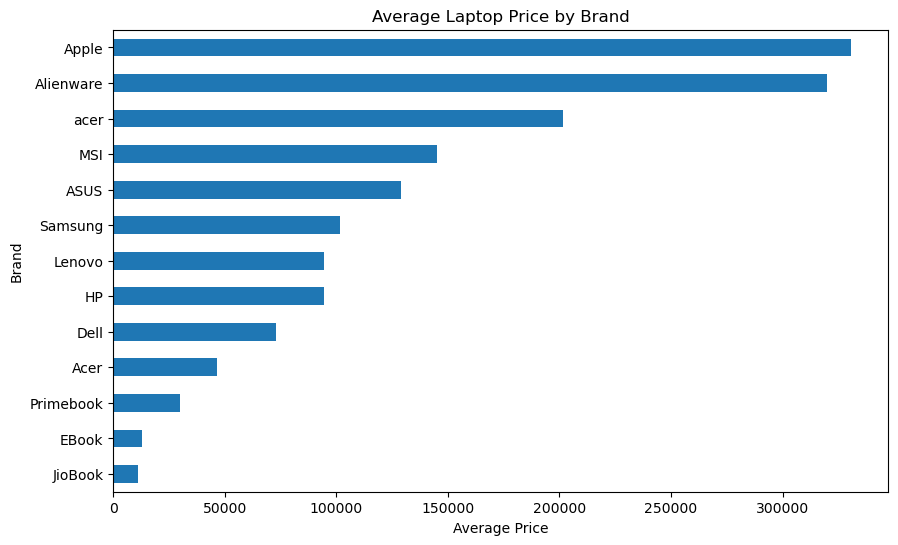

In [252]:
brand_price.plot(kind='barh',figsize=(10,6))

plt.xlabel('Average Price')
plt.ylabel('Brand')
plt.title('Average Laptop Price by Brand')
plt.show()

In [39]:
df1['Processor_group']

0      Intel Core 7/i7
1                Other
2          AMD Ryzen 5
3      Intel Core 3/i3
4       Apple M-series
            ...       
217              Other
218        AMD Ryzen 7
219        AMD Ryzen 7
220        AMD Ryzen 5
221        AMD Ryzen 3
Name: Processor_group, Length: 222, dtype: object

In [200]:
df1[df1['Processor_group']=='Other']

,Brand_name,Processor,RAM,SSD,Screen_Size,Price,Discount,Rating,Processor_group,Storage_GB
1,ASUS,Intel Core U,16.0,1TB SSD,14.0,189990.0,34.0,0.0,Other,1000.0
25,HP,Intel Core U,24.0,1TB SSD,14.0,89999.0,35.0,3.6,Other,1000.0
26,ASUS,Intel Core U,16.0,512GB SSD,14.0,93990.0,6.0,4.1,Other,512.0
28,ASUS,Intel Core U,32.0,1TB SSD,14.0,278990.0,9.0,0.0,Other,1000.0
31,Samsung,Intel Core U,16.0,512GB SSD,14.0,112990.0,21.0,3.0,Other,512.0
32,ASUS,Intel Core U,16.0,1TB SSD,16.0,149990.0,30.0,0.0,Other,1000.0
36,Lenovo,Intel Core U,16.0,512GB SSD,16.0,98990.0,32.0,3.9,Other,512.0
52,Samsung,Intel Core U,16.0,512GB SSD,16.0,121590.0,26.0,2.5,Other,512.0
60,ASUS,Intel Core U,16.0,512GB SSD,14.0,167990.0,38.0,0.0,Other,512.0
63,Acer,Intel Core U,16.0,512 GB SSD,14.0,72990.0,27.0,4.1,Other,512.0


In [201]:
df1.loc[(df1['Processor_group']=='Other') & (df1['Processor'].str.contains('Intel Core U')), 'Processor_group']='Intel Core U'

In [207]:
df1['Processor_group']

0      Intel Core 7/i7
1         Intel Core U
2          AMD Ryzen 5
3      Intel Core 3/i3
4       Apple M-series
            ...       
216        AMD Ryzen 3
218        AMD Ryzen 7
219        AMD Ryzen 7
220        AMD Ryzen 5
221        AMD Ryzen 3
Name: Processor_group, Length: 160, dtype: object

In [253]:
df1['Processor_group'].value_counts()

Processor_group
Intel Core U        25
Intel Core 5/i5     25
AMD Ryzen 5         16
Intel Core 7/i7     15
Intel Core 3/i3     15
AMD Ryzen 3         14
AMD Ryzen 7         12
MediaTek             8
Apple M-series       8
Intel Celeron        6
Other                4
Snapdragon           3
AMD Athlon           2
AMD Ryzen 9          2
Intel Core 9/i9      2
Intel N-series       1
Intel Core Ultra     1
Intel Pentium        1
Name: count, dtype: int64

In [254]:
df1.loc[(df1['Processor_group']=='Other') & (df1['Processor'].str.contains('i9')), 'Processor_group']='Intel Core 9/i9'

In [256]:
df1.loc[(df1['Processor_group']=='Other') & (df1['Processor'].str.contains('i5')), 'Processor_group']='Intel Core 5/i5'

In [257]:
df1[df1['Processor_group']=='Other']

,Brand_name,Processor,RAM,SSD,Screen_Size,Price,Discount,Rating,Processor_group,Storage_GB
76,HP,Intel,8.0,512 GB SSD,15.6,45450.0,55.0,2.9,Other,512.0
115,HP,M365,8.0,1TB SSD,16.0,162490.0,26.0,4.4,Other,1000.0
190,ASUS,M365,32.0,1 TB,14.0,269990.0,25.0,0.0,Other,1000.0
209,ASUS,M365,16.0,512GB SSD,14.0,93990.0,0.0,4.3,Other,512.0


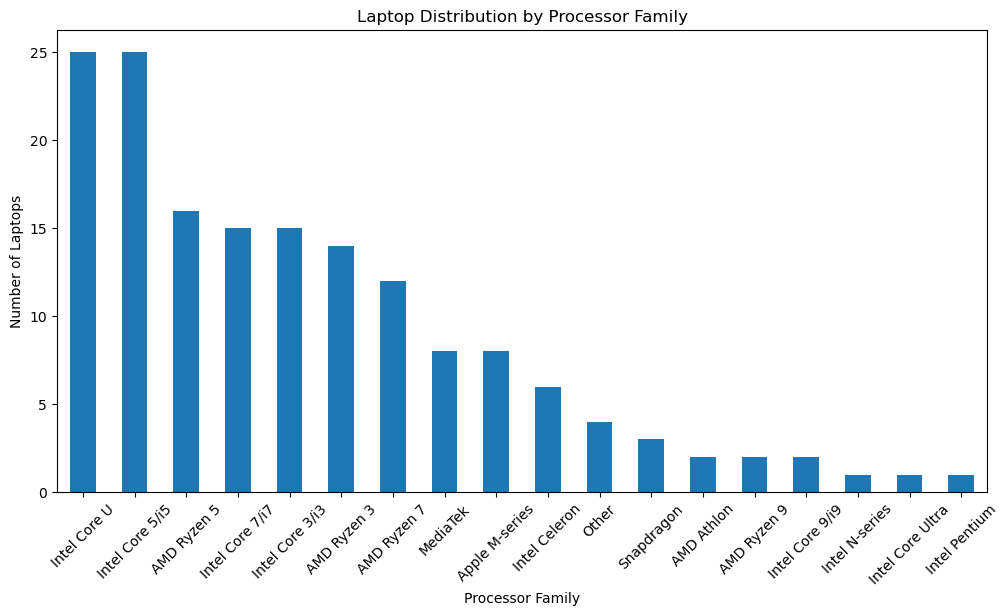

In [258]:
df1['Processor_group'].value_counts().plot(kind='bar', figsize=(12,6))

plt.xlabel('Processor Family')
plt.ylabel('Number of Laptops')
plt.title('Laptop Distribution by Processor Family')
plt.xticks(rotation=45)
plt.show()

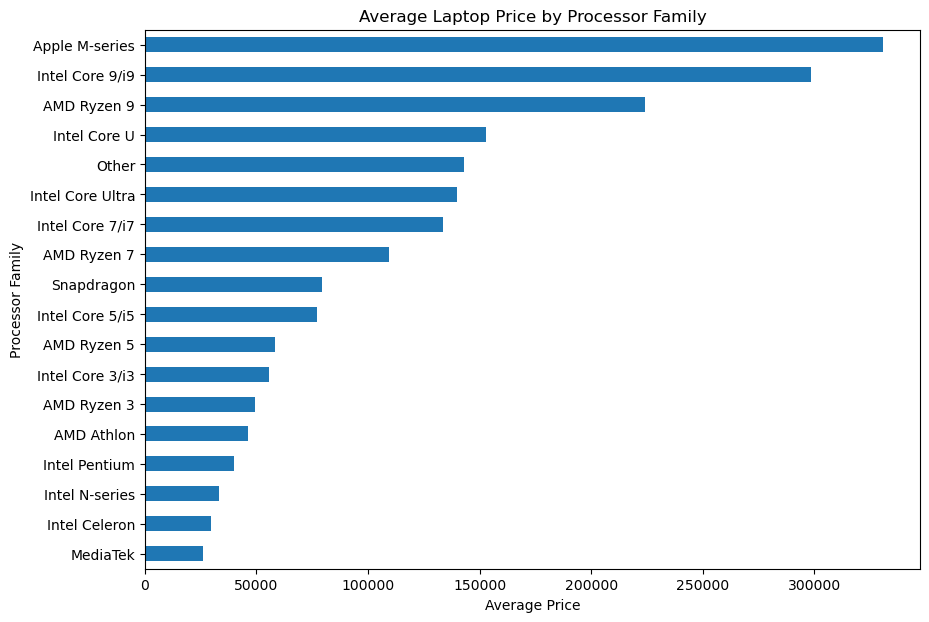

In [259]:
processor_price = df1.groupby('Processor_group')['Price'].mean().sort_values()

processor_price.plot(kind='barh',figsize=(10,7))

plt.xlabel('Average Price')
plt.ylabel('Processor Family')
plt.title('Average Laptop Price by Processor Family')
plt.show()

In [260]:
df1['RAM'].value_counts().sort_index()

RAM
4.0      9
6.0      5
8.0     47
12.0     1
16.0    84
24.0     5
32.0     6
36.0     2
48.0     1
Name: count, dtype: int64

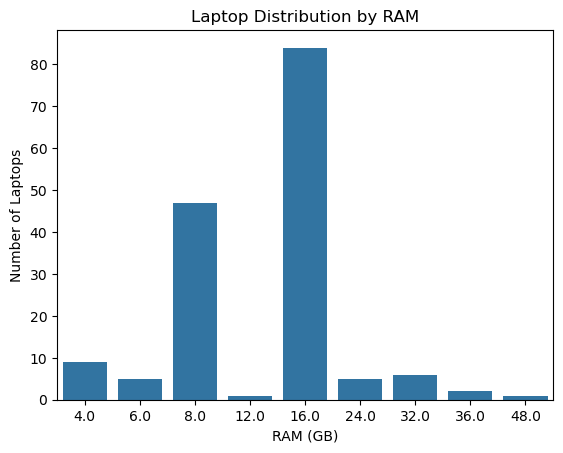

In [261]:
sns.countplot(data=df1,x='RAM')

plt.xlabel('RAM (GB)')
plt.ylabel('Number of Laptops')
plt.title('Laptop Distribution by RAM')
plt.show()

[Text(0, 0, '84'),
 Text(0, 0, '47'),
 Text(0, 0, '9'),
 Text(0, 0, '6'),
 Text(0, 0, '5'),
 Text(0, 0, '5'),
 Text(0, 0, '2'),
 Text(0, 0, '1'),
 Text(0, 0, '1')]

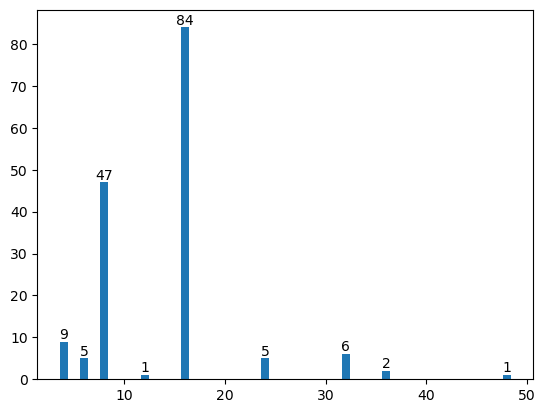

In [262]:
brand_counts = df1['RAM'].value_counts()

bars = plt.bar(brand_counts.index, brand_counts.values)

plt.bar_label(bars)

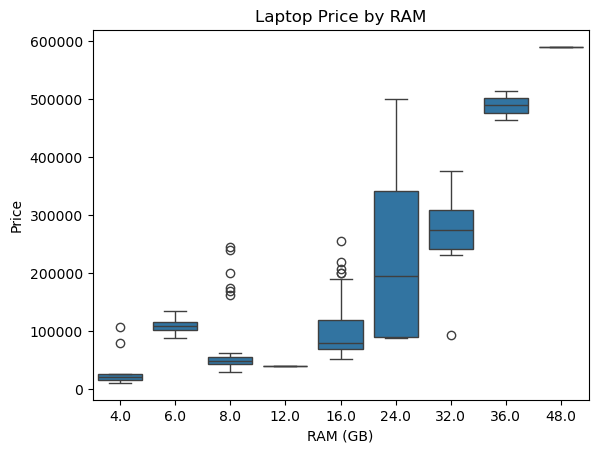

In [128]:
sns.boxplot(data=df1,x='RAM',y='Price')

plt.xlabel('RAM (GB)')
plt.ylabel('Price')
plt.title('Laptop Price by RAM')
plt.show()

In [75]:
df1['Storage_GB'].value_counts().sort_index()

Storage_GB
32.0        1
64.0        4
128.0       3
256.0       9
500.0       1
512.0     119
1000.0     57
2000.0     16
Name: count, dtype: int64

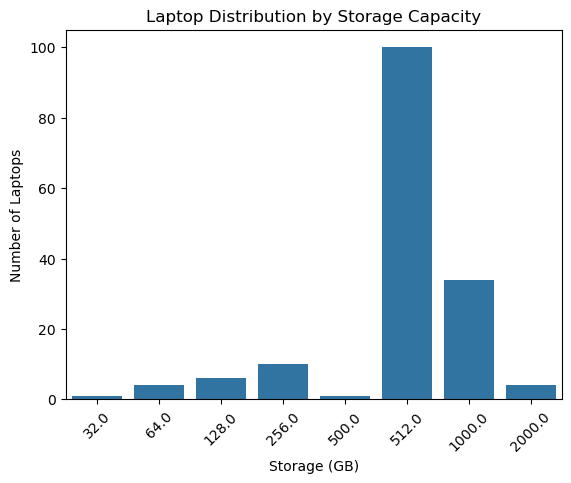

In [263]:
sns.countplot(data=df1,x='Storage_GB')

plt.xticks(rotation=45)
plt.xlabel('Storage (GB)')
plt.ylabel('Number of Laptops')
plt.title('Laptop Distribution by Storage Capacity')
plt.show()

[Text(0, 0, '100'),
 Text(0, 0, '34'),
 Text(0, 0, '10'),
 Text(0, 0, '6'),
 Text(0, 0, '4'),
 Text(0, 0, '4'),
 Text(0, 0, '1'),
 Text(0, 0, '1')]

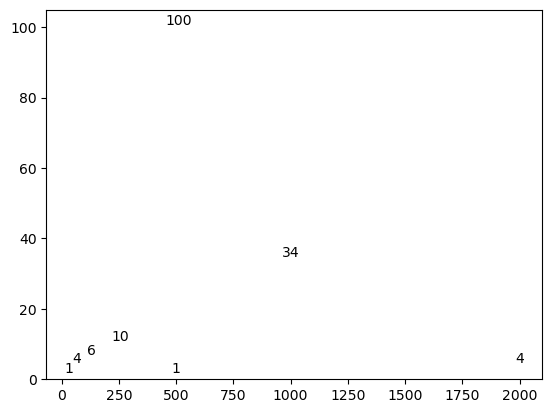

In [264]:
Storage_counts = df1['Storage_GB'].value_counts()

bars = plt.bar(Storage_counts.index, Storage_counts.values)

plt.bar_label(bars)

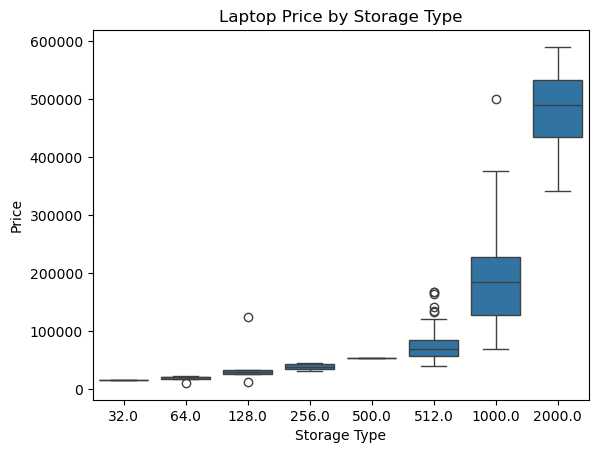

In [265]:
sns.boxplot(data=df1,x='Storage_GB',y='Price')

plt.xlabel('Storage Type')
plt.ylabel('Price')
plt.title('Laptop Price by Storage Type')
plt.show()

In [267]:
threshold = df1['Price'].quantile(0.75)
threshold

np.float64(119690.0)

In [268]:
premium[['Brand_name', 'Processor', 'RAM', 'SSD', 'Price', 'Rating']]

,Brand_name,Processor,RAM,SSD,Price,Rating
1,ASUS,Intel Core U,16.0,1TB SSD,189990.0,NaN
4,Apple,M5,16.0,1TB SSD,172490.0,4.7
5,Apple,M5,16.0,512GB SSD,166990.0,4.8
8,Apple,M5 Max,48.0,2TB SSD,589990.0,4.4
9,Apple,M5 Max,36.0,2TB SSD,464490.0,5.0
24,Apple,M5 Pro,24.0,2TB SSD,342490.0,4.6
28,ASUS,Intel Core U,32.0,1TB SSD,278990.0,NaN
32,ASUS,Intel Core U,16.0,1TB SSD,149990.0,NaN
47,Apple,M5,16.0,1TB SSD,200990.0,4.8
52,Samsung,Intel Core U,16.0,512GB SSD,121590.0,2.5


In [269]:
premium = df1[df1['Price'] >= threshold]

In [270]:
df1['Laptop_segment']=df1['Price'].apply(lambda x:'Premium' if x>=threshold else 'Not_Premium')
df1

C:\Users\Ravi Teja G\AppData\Local\Temp\ipykernel_6704\1901704941.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Laptop_segment']=df1['Price'].apply(lambda x:'Premium' if x>=threshold else 'Not_Premium')


,Brand_name,Processor,RAM,SSD,Screen_Size,Price,Discount,Rating,Processor_group,Storage_GB,Laptop_segment
0,ASUS,Intel Core 7 350,16.0,512GB SSD,14.0,118990.0,34.0,0.0,Intel Core 7/i7,512.0,Not_Premium
1,ASUS,Intel Core U,16.0,1TB SSD,14.0,189990.0,34.0,0.0,Intel Core U,1000.0,Premium
2,Lenovo,AMD Ryzen 5 7520U,16.0,512,15.6,58090.0,39.0,4.0,AMD Ryzen 5,512.0,Not_Premium
3,Dell,Intel Core i3/Core 3 100U,16.0,512 SSD,15.6,60490.0,17.0,4.0,Intel Core 3/i3,512.0,Not_Premium
4,Apple,M5,16.0,1TB SSD,13.0,172490.0,7.0,4.7,Apple M-series,1000.0,Premium
...,...,...,...,...,...,...,...,...,...,...,...
216,Acer,AMD Ryzen 3-5400U,8.0,512GB SSD,15.6,44490.0,25.0,1.0,AMD Ryzen 3,512.0,Not_Premium
218,Lenovo,AMD Ryzen 7,16.0,1TB SSD,15.6,199990.0,3.0,3.5,AMD Ryzen 7,1000.0,Premium
219,ASUS,AMD Ryzen 7 8845HS,4.0,512GB SSD,15.6,107990.0,31.0,3.9,AMD Ryzen 7,512.0,Not_Premium
220,Lenovo,AMD Ryzen 5 7520U,16.0,512GB SSD,15.6,59999.0,37.0,3.6,AMD Ryzen 5,512.0,Not_Premium


In [271]:
df1['Laptop_segment'].value_counts()

Laptop_segment
Not_Premium    120
Premium         40
Name: count, dtype: int64

In [272]:
df1['Laptop_segment'].value_counts(normalize=True) * 100

Laptop_segment
Not_Premium    75.0
Premium        25.0
Name: proportion, dtype: float64

In [273]:
premium = df1[df1['Laptop_segment'] == 'Premium']

In [274]:
premium['Brand_name'].value_counts()

Brand_name
HP           10
ASUS          8
Apple         8
Lenovo        8
MSI           2
Samsung       1
Dell          1
Alienware     1
acer          1
Name: count, dtype: int64

In [278]:
premium['Processor_group'].value_counts()

Processor_group
Intel Core U        14
Apple M-series       8
Intel Core 7/i7      7
AMD Ryzen 7          3
Other                2
AMD Ryzen 9          2
Intel Core 9/i9      2
Intel Core 5/i5      1
Intel Core Ultra     1
Name: count, dtype: int64

In [279]:
premium['RAM'].value_counts().sort_index()

RAM
6.0      1
8.0      6
16.0    22
24.0     3
32.0     5
36.0     2
48.0     1
Name: count, dtype: int64

In [280]:
premium['Storage_GB'].value_counts().sort_index()

Storage_GB
128.0      1
512.0      9
1000.0    26
2000.0     4
Name: count, dtype: int64

In [282]:
df1['Rating'] = df1['Rating'].replace(0, np.nan)

C:\Users\Ravi Teja G\AppData\Local\Temp\ipykernel_6704\921746517.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Rating'] = df1['Rating'].replace(0, np.nan)


In [283]:
df1

,Brand_name,Processor,RAM,SSD,Screen_Size,Price,Discount,Rating,Processor_group,Storage_GB,Laptop_segment
0,ASUS,Intel Core 7 350,16.0,512GB SSD,14.0,118990.0,34.0,NaN,Intel Core 7/i7,512.0,Not_Premium
1,ASUS,Intel Core U,16.0,1TB SSD,14.0,189990.0,34.0,NaN,Intel Core U,1000.0,Premium
2,Lenovo,AMD Ryzen 5 7520U,16.0,512,15.6,58090.0,39.0,4.0,AMD Ryzen 5,512.0,Not_Premium
3,Dell,Intel Core i3/Core 3 100U,16.0,512 SSD,15.6,60490.0,17.0,4.0,Intel Core 3/i3,512.0,Not_Premium
4,Apple,M5,16.0,1TB SSD,13.0,172490.0,7.0,4.7,Apple M-series,1000.0,Premium
...,...,...,...,...,...,...,...,...,...,...,...
216,Acer,AMD Ryzen 3-5400U,8.0,512GB SSD,15.6,44490.0,25.0,1.0,AMD Ryzen 3,512.0,Not_Premium
218,Lenovo,AMD Ryzen 7,16.0,1TB SSD,15.6,199990.0,3.0,3.5,AMD Ryzen 7,1000.0,Premium
219,ASUS,AMD Ryzen 7 8845HS,4.0,512GB SSD,15.6,107990.0,31.0,3.9,AMD Ryzen 7,512.0,Not_Premium
220,Lenovo,AMD Ryzen 5 7520U,16.0,512GB SSD,15.6,59999.0,37.0,3.6,AMD Ryzen 5,512.0,Not_Premium


In [284]:
df1['Rating'].describe()

count    136.000000
mean       3.862500
std        0.699305
min        1.000000
25%        3.600000
50%        4.000000
75%        4.200000
max        5.000000
Name: Rating, dtype: float64

<Axes: xlabel='Rating'>

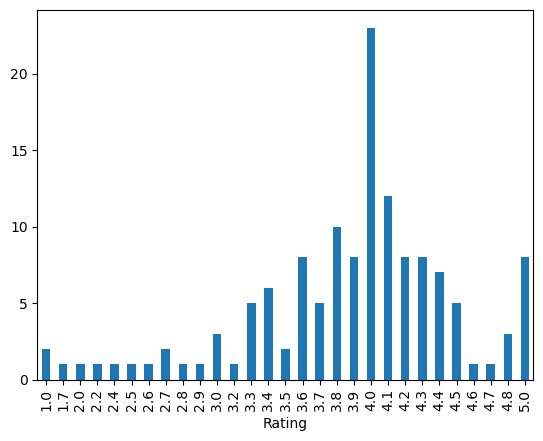

In [285]:
df1['Rating'].value_counts().sort_index().plot(kind='bar')

In [286]:
def rating_group(x):
    if x >= 4.5:
        return 'Excellent'
    elif x >= 4.0:
        return 'Good'
    elif x >= 3.0:
        return 'Average'
    else:
        return 'Poor'


df1['rating_group'] = df1['Rating'].apply(rating_group)

C:\Users\Ravi Teja G\AppData\Local\Temp\ipykernel_6704\3776741414.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['rating_group'] = df1['Rating'].apply(rating_group)


In [287]:
df1['rating_group']

0           Poor
1           Poor
2           Good
3           Good
4      Excellent
         ...    
216         Poor
218      Average
219      Average
220      Average
221         Poor
Name: rating_group, Length: 160, dtype: object

In [160]:
df1['rating_group'].value_counts()

rating_group
Good         58
Average      48
Poor         36
Excellent    18
Name: count, dtype: int64

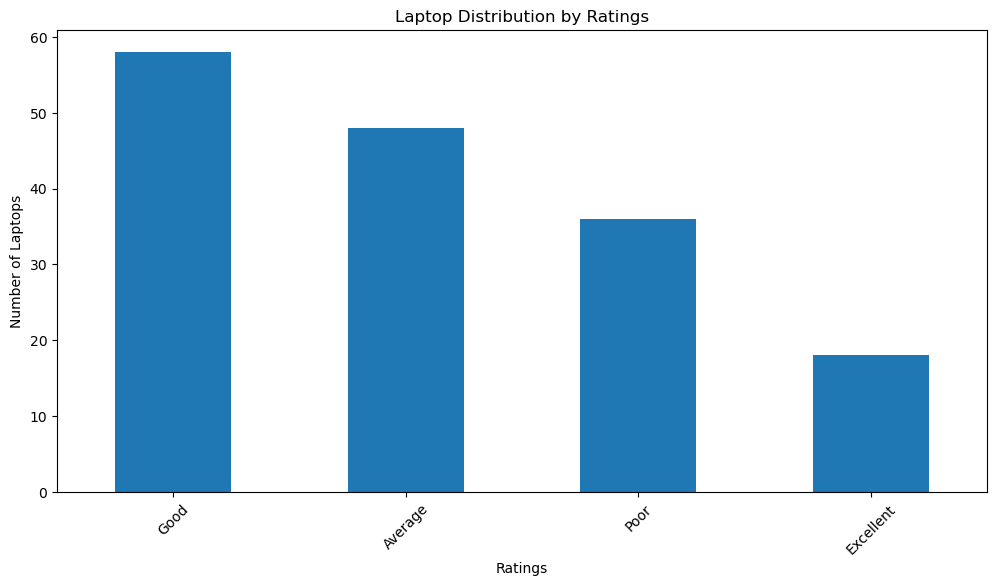

In [162]:
df1['Rating_Group'].value_counts().plot(kind='bar', figsize=(12,6))

plt.xlabel('Ratings')
plt.ylabel('Number of Laptops')
plt.title('Laptop Distribution by Ratings')
plt.xticks(rotation=45)
plt.show()

In [289]:
pd.crosstab(df1['Laptop_segment'], df1['rating_group'])

rating_group,Average,Excellent,Good,Poor
Laptop_segment,,,,
Not_Premium,43,9,46,22
Premium,5,9,12,14


<Axes: xlabel='Laptop_segment'>

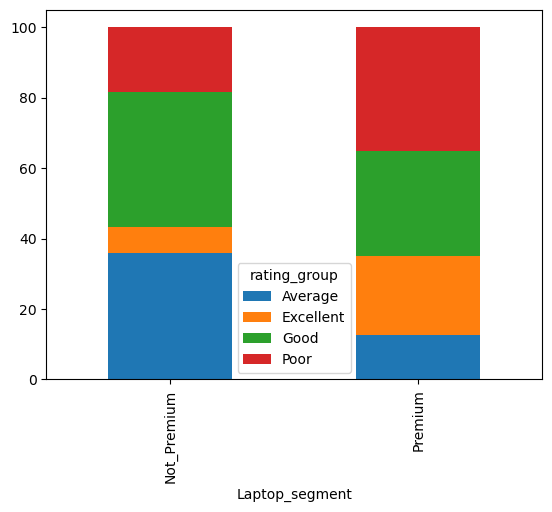

In [165]:
rating_segment = pd.crosstab(df1['Laptop_segment'],df1['rating_group'],normalize='index') * 100

rating_segment.plot(kind='bar',stacked=True)

In [290]:
pd.crosstab(df1['Laptop_segment'],df1['rating_group'],normalize='index') * 100

rating_group,Average,Excellent,Good,Poor
Laptop_segment,,,,
Not_Premium,35.833333,7.5,38.333333,18.333333
Premium,12.500000,22.5,30.000000,35.000000


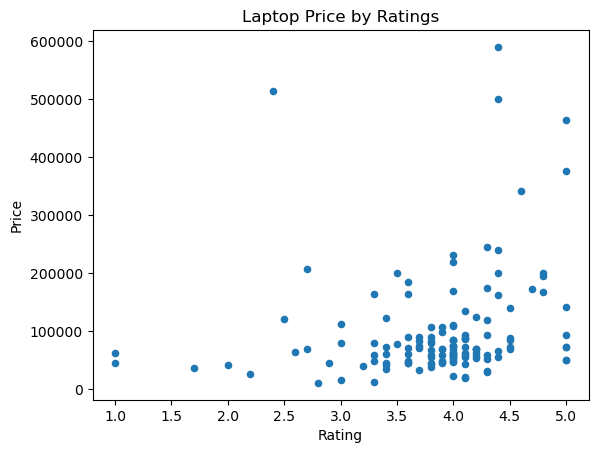

In [168]:
df1.plot.scatter(x='Rating', y='Price')

plt.title('Laptop Price by Ratings')
plt.show()